# 00. セットアップ動作確認

このノートブックは **教材を始める前の健康診断** です。上のセルから順に `Shift` + `Enter` で実行してください。

確認すること:

1. 正しい Python 環境（`.venv` / Python 3.11）で動いているか
2. 必要なライブラリが全部入っているか
3. グラフの日本語が文字化けしないか
4. Binance API に接続できるか

**すべて ✅ になれば Vol.01 に進んで大丈夫です。**

---
## 1. Python 環境の確認

In [1]:
import sys, os, pathlib

print(f"Python バージョン : {sys.version.split()[0]}")
print(f"実行中の python   : {sys.executable}")
print(f"作業フォルダ      : {os.getcwd()}")
print("-" * 60)

ok = True

major, minor = sys.version_info[:2]
if (major, minor) == (3, 11):
    print("✅ Python 3.11 で動いています")
elif (major, minor) >= (3, 12):
    ok = False
    print(f"❌ Python {major}.{minor} で動いています。")
    print("   japanize-matplotlib は Python 3.12 以降では動きません。")
    print("   手順書の『つまずきポイント集』を見て .venv を作り直してください。")
else:
    print(f"⚠️  Python {major}.{minor} です。動く可能性は高いですが 3.11 を推奨します。")

if ".venv" in sys.executable.replace("\\", "/"):
    print("✅ 教材フォルダの .venv を使っています")
else:
    ok = False
    print("❌ .venv ではない Python を使っています。")
    print("   右上の『カーネルの選択』から .venv (Python 3.11.x) を選び直してください。")

Python バージョン : 3.11.15
実行中の python   : d:\crypto-data-analysis-course\.venv\Scripts\python.exe
作業フォルダ      : d:\crypto-data-analysis-course
------------------------------------------------------------
✅ Python 3.11 で動いています
✅ 教材フォルダの .venv を使っています


---
## 2. ライブラリの確認

In [2]:
import importlib

libs = {
    "requests":            "Binance API からのデータ取得",
    "pandas":              "表形式データの操作",
    "numpy":               "数値計算",
    "matplotlib":          "グラフ描画",
    "japanize_matplotlib": "グラフの日本語表示",
    "scipy":               "統計検定（Vol.02 以降）",
}

missing = []
for name, use in libs.items():
    try:
        m = importlib.import_module(name)
        ver = getattr(m, "__version__", "-")
        print(f"✅ {name:<22} {ver:<12} {use}")
    except Exception as e:
        missing.append(name)
        print(f"❌ {name:<22} {'':<12} {use}")
        print(f"     → {type(e).__name__}: {e}")

print("-" * 70)
if missing:
    print("不足しているライブラリがあります。ターミナルで次を実行してください:")
    print("  uv pip install " + " ".join(n.replace("_", "-") for n in missing))
else:
    print("✅ 必要なライブラリはすべて揃っています")

✅ requests               2.34.2       Binance API からのデータ取得
✅ pandas                 3.0.5        表形式データの操作
✅ numpy                  2.4.6        数値計算
✅ matplotlib             3.11.1       グラフ描画
✅ japanize_matplotlib    -            グラフの日本語表示
✅ scipy                  1.17.1       統計検定（Vol.02 以降）
----------------------------------------------------------------------
✅ 必要なライブラリはすべて揃っています


---
## 3. グラフの日本語表示の確認

下に折れ線グラフが表示されます。**タイトルと軸ラベルの日本語が読めれば OK** です。
`□□□`（豆腐）になっている場合は日本語フォントが効いていません。

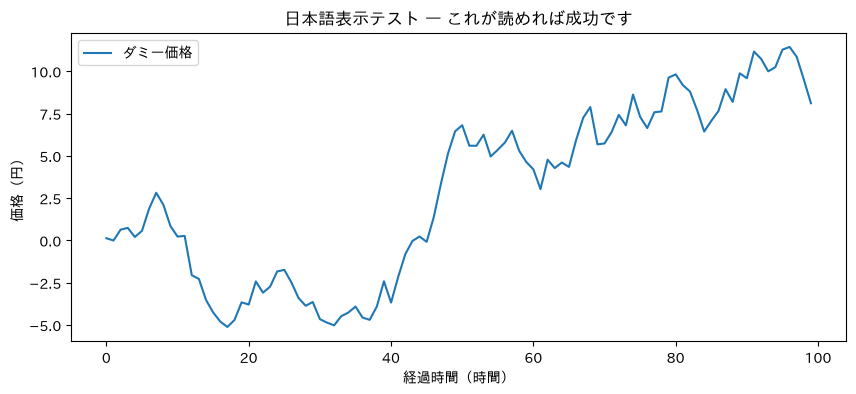

↑ タイトル・軸ラベル・凡例の日本語が読めれば ✅
   □□□ になっている場合は、このセルを上から実行し直してください。


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  ← import するだけで日本語対応になる

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

x = np.arange(100)
y = np.cumsum(np.random.default_rng(0).normal(0, 1, 100))

fig, ax = plt.subplots()
ax.plot(x, y, label="ダミー価格")
ax.set_title("日本語表示テスト — これが読めれば成功です")
ax.set_xlabel("経過時間（時間）")
ax.set_ylabel("価格（円）")
ax.legend()
plt.show()

print("↑ タイトル・軸ラベル・凡例の日本語が読めれば ✅")
print("   □□□ になっている場合は、このセルを上から実行し直してください。")

---
## 4. Binance API 接続の確認

教材は Binance の公開 API からリアルタイムにデータを取得します（API キー不要）。
ここで接続できるかを確認します。

In [4]:
import requests

HOSTS = [
    ("https://api.binance.com/api/v3/klines",         "本家エンドポイント"),
    ("https://data-api.binance.vision/api/v3/klines",  "公開データ用ミラー"),
]
params = {"symbol": "BTCUSDT", "interval": "1h", "limit": 3}

working = None
for url, label in HOSTS:
    try:
        r = requests.get(url, params=params, timeout=15)
        if r.status_code == 200:
            print(f"✅ {label:<20} 接続成功  ({url})")
            if working is None:
                working = url
                last = r.json()[-1]
                import pandas as pd
                ts = pd.to_datetime(last[0], unit="ms", utc=True)
                print(f"   最新の1時間足: {ts:%Y-%m-%d %H:%M} UTC  終値 {float(last[4]):,.2f} USDT")
        elif r.status_code == 451:
            print(f"❌ {label:<20} 451 地域制限でブロックされました  ({url})")
        else:
            print(f"❌ {label:<20} HTTP {r.status_code}  ({url})")
    except Exception as e:
        print(f"❌ {label:<20} {type(e).__name__}: {str(e)[:100]}")

print("-" * 70)
if working is None:
    print("どちらにも接続できませんでした。ネットワーク接続やプロキシ設定を確認してください。")
elif "binance.vision" in working:
    print("本家がブロックされています。教材の中の")
    print('  BINANCE_API_URL = "https://api.binance.com/api/v3/klines"')
    print("を次に書き換えて進めてください:")
    print('  BINANCE_API_URL = "https://data-api.binance.vision/api/v3/klines"')
else:
    print("✅ 教材のコードをそのまま実行できます")

✅ 本家エンドポイント            接続成功  (https://api.binance.com/api/v3/klines)
   最新の1時間足: 2026-08-13 03:00 UTC  終値 63,531.48 USDT
✅ 公開データ用ミラー            接続成功  (https://data-api.binance.vision/api/v3/klines)
----------------------------------------------------------------------
✅ 教材のコードをそのまま実行できます


---
## 結果の読み方

- **すべて ✅** → `vol01_data_acquisition_and_cleansing.ipynb` を開いて始めてください。
- **❌ がある** → 同じフォルダの `SETUP_VSCode_ja.md` の「つまずきポイント集」に対処法があります。
  （VS Code でこのファイルを開いて `Ctrl` + `Shift` + `V` でプレビュー表示できます）